<a href="https://colab.research.google.com/github/CeSaRLoPeZArTeAgA/Modelos_de_Aprendizaje_Automatico-IMCA/blob/main/Clase_2_OM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos del Aprendizaje Automatico - MMC214

---


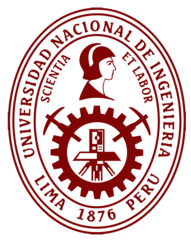

---
#CLASE 2 - REGRESION LOGISTICA PARA TWITTER
---

In [ ]:
#importacion de librerias requeridas
import nltk
from os import getcwd

In [ ]:
nltk.download('twitter_samples')
nltk.download('stopwords')

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
filePath = f"{getcwd()}/../tmp2/"
nltk.data.path.append(filePath)

In [ ]:
import numpy as np
import pandas as pd
from nltk.corpus import twitter_samples

In [ ]:
all_positive_tweets=twitter_samples.strings('positive_tweets.json')
all_negative_tweets=twitter_samples.strings('negative_tweets.json')

In [ ]:
all_positive_tweets

['#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)',
 '@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!',
 '@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!',
 '@97sides CONGRATS :)',
 'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days',
 '@BhaktisBanter @PallaviRuhail This one is irresistible :)\n#FlipkartFashionFriday http://t.co/EbZ0L2VENM',
 "We don't like to keep our lovely customers waiting for long! We hope you enjoy! Happy Friday! - LWWF :) https://t.co/smyYriipxI",
 '@Impatientraider On second thought, there’s just not enough time for a DD :) But new shorts entering system. Sheep must be buying.',
 'Jgh , but we have to go to Bayan :D bye',
 'As an act of mischievousness, am calling the ETL layer of our in-house warehousing 

In [ ]:
all_negative_tweets

['hopeless for tmr :(',
 "Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(",
 '@Hegelbon That heart sliding into the waste basket. :(',
 '“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too',
 'Dang starting next week I have "work" :(',
 "oh god, my babies' faces :( https://t.co/9fcwGvaki0",
 '@RileyMcDonough make me smile :((',
 '@f0ggstar @stuartthull work neighbour on motors. Asked why and he said hates the updates on search :( http://t.co/XvmTUikWln',
 'why?:("@tahuodyy: sialan:( https://t.co/Hv1i0xcrL2"',
 'Athabasca glacier was there in #1948 :-( #athabasca #glacier #jasper #jaspernationalpark #alberta #explorealberta #… http://t.co/dZZdqmf7Cz',
 "I have a really good m&amp;g idea but I'm never going to meet them :(((",
 '@Rampageinthebox mare ivan :(',
 '@SophiaMascardo happy trip, keep safe. see you soon :* :(',
 "I'm so tired hahahah :(",
 '@GrumpyCockney With knee replacements they get you up &amp; about the same day. :-(   Ou

In [ ]:
#La data original son 5000 datos, se separa 4000 para entrenamiento y 1000 para testeo
train_pos=all_positive_tweets[:4000]#para entrenamiento de positivo, los primeros 4000
test_pos=all_positive_tweets[4000:]#para el testeo para lo positivo, los ultimos 1000
train_neg=all_negative_tweets[:4000]#para entrenamiento de negative
test_neg=all_negative_tweets[4000:]#para el testeo para de negativo

In [ ]:
train_x=train_pos+train_neg#toda la data tanto positivo como negativo para el entrenamiento
test_x=test_pos+test_neg #toda la data tanto positivo como negativo para el testeo

In [ ]:
train_y=np.append(np.ones((len(train_pos),1)),np.zeros((len(train_neg),1)),axis=0)#para el entrenamiento
test_y=np.append(np.ones((len(test_pos),1)),np.zeros((len(test_neg),1)),axis=0)#para el testeo

In [ ]:
train_y.shape

(8000, 1)

In [ ]:
train_x

['#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)',
 '@Lamb2ja Hey James! How odd :/ Please call our Contact Centre on 02392441234 and we will be able to assist you :) Many thanks!',
 '@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!',
 '@97sides CONGRATS :)',
 'yeaaaah yippppy!!!  my accnt verified rqst has succeed got a blue tick mark on my fb profile :) in 15 days',
 '@BhaktisBanter @PallaviRuhail This one is irresistible :)\n#FlipkartFashionFriday http://t.co/EbZ0L2VENM',
 "We don't like to keep our lovely customers waiting for long! We hope you enjoy! Happy Friday! - LWWF :) https://t.co/smyYriipxI",
 '@Impatientraider On second thought, there’s just not enough time for a DD :) But new shorts entering system. Sheep must be buying.',
 'Jgh , but we have to go to Bayan :D bye',
 'As an act of mischievousness, am calling the ETL layer of our in-house warehousing 

In [ ]:
train_y

array([[1.],
       [1.],
       [1.],
       ...,
       [0.],
       [0.],
       [0.]])

In [ ]:
test_y.shape

(2000, 1)

In [ ]:
#limpia el twiteer de @, y otras simbolos
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer#metodo para tomar la raiz de la palabra
from nltk.tokenize import TweetTokenizer#separar en palabras

def process_tweet(tweet):
    """Process tweet function.
    Input:
        tweet: a string containing a tweet
    Output:
        tweets_clean: a list of words containing the processed tweet

    """
    stemmer = PorterStemmer()
    stopwords_english = stopwords.words('english')
    # remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet = re.sub(r'https?:\/\/.[\r\n]', '', tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)
    # tokenize tweets
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)

    return tweets_clean

In [ ]:
train_x[0]

'#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)'

In [ ]:
process_tweet(train_x[0])

['followfriday', 'top', 'engag', 'member', 'commun', 'week', ':)']

In [ ]:
def build_freqs(tweets, ys):
    """Build frequencies.
    Input:
        tweets: a list of tweets
        ys: an m x 1 array with the sentiment label of each tweet
            (either 0 or 1)
    Output:
        freqs: a dictionary mapping each (word, sentiment) pair to its
        frequency
    """
    # Convert np array to list since zip needs an iterable.
    # The squeeze is necessary or the list ends up with one element.
    # Also note that this is just a NOP if ys is already a list.
    yslist = np.squeeze(ys).tolist()

    # Start with an empty dictionary and populate it by looping over all tweets
    # and over all processed words in each tweet.
    freqs = {}
    for y, tweet in zip(yslist, tweets):
        for word in process_tweet(tweet):
            pair = (word, y)
            if pair in freqs:
                freqs[pair] += 1
            else:
                freqs[pair] = 1

    return freqs

In [ ]:
freqs=build_freqs(train_x,train_y)

In [ ]:
freqs

{('followfriday', 1.0): 23,
 ('top', 1.0): 30,
 ('engag', 1.0): 7,
 ('member', 1.0): 14,
 ('commun', 1.0): 27,
 ('week', 1.0): 72,
 (':)', 1.0): 2960,
 ('hey', 1.0): 60,
 ('jame', 1.0): 7,
 ('odd', 1.0): 2,
 (':/', 1.0): 5,
 ('pleas', 1.0): 81,
 ('call', 1.0): 27,
 ('contact', 1.0): 4,
 ('centr', 1.0): 1,
 ('02392441234', 1.0): 1,
 ('abl', 1.0): 6,
 ('assist', 1.0): 1,
 ('mani', 1.0): 28,
 ('thank', 1.0): 522,
 ('listen', 1.0): 15,
 ('last', 1.0): 39,
 ('night', 1.0): 55,
 ('bleed', 1.0): 2,
 ('amaz', 1.0): 41,
 ('track', 1.0): 5,
 ('scotland', 1.0): 2,
 ('congrat', 1.0): 15,
 ('yeaaah', 1.0): 1,
 ('yipppi', 1.0): 1,
 ('accnt', 1.0): 2,
 ('verifi', 1.0): 2,
 ('rqst', 1.0): 1,
 ('succeed', 1.0): 1,
 ('got', 1.0): 57,
 ('blue', 1.0): 8,
 ('tick', 1.0): 1,
 ('mark', 1.0): 1,
 ('fb', 1.0): 4,
 ('profil', 1.0): 2,
 ('15', 1.0): 4,
 ('day', 1.0): 187,
 ('one', 1.0): 92,
 ('irresist', 1.0): 2,
 ('flipkartfashionfriday', 1.0): 16,
 ('http://t.co/ebz0l2venm', 1.0): 1,
 ('like', 1.0): 187,
 ('ke

In [ ]:
def sigmoid(z):
    '''
    Input:
        z: is the input (can be a scalar or an array)
    Output:
        h: the sigmoid of z
    '''

    # calculate the sigmoid of z
    h = 1/(1+np.exp(-z))

    return h

In [ ]:
def gradientDescent(x, y, theta, alpha, num_iters):
    '''
    Input:
        x: matrix of features which is (m,n+1)
        y: corresponding labels of the input matrix x, dimensions (m,1)
        theta: weight vector of dimension (n+1,1)
        alpha: learning rate
        num_iters: number of iterations you want to train your model for
    Output:
        J: the final cost
        theta: your final weight vector
        '''
    # get 'm', the number of rows in matrix x
    m = len(x)

    for i in range(0, num_iters):

        # get z, the dot product of x and theta
        z = np.dot(x,theta)

        # get the sigmoid of z
        h = sigmoid(z)

        # calculate the cost function
        J = -(1/m) * (np.dot(np.transpose(y), np.log(h)) +  np.dot(np.transpose(1-y), np.log(1-h)))

        # update the weights theta
        theta = theta - (alpha/m)*(np.dot(np.transpose(x),(h-y)))

    J = float(J)
    return J, theta

In [ ]:
def extract_features(tweet, freqs):
    '''
    Input:
        tweet: a list of words for one tweet
        freqs: a dictionary corresponding to the frequencies of each tuple (word, label)
    Output:
        x: a feature vector of dimension (1,)
    '''
    word_l=process_tweet(tweet)
    x=np.zeros((1,3))
    x[0,0]=1
    for word in word_l:
      if (word,1) in freqs:
          x[0,1]+=freqs[(word,1)]
      if (word,0) in freqs:
          x[0,2]+=freqs[(word,0)]

    return x

In [ ]:
extract_features('amazing amazing',freqs)

array([[ 1., 82., 24.]])

In [ ]:
extract_features('amazing',freqs)

array([[ 1., 41., 12.]])

In [ ]:
extract_features('amazing good',freqs)

array([[  1., 232.,  95.]])

In [ ]:
X=np.zeros((len(train_x),3))
for i in range(len(train_x)):
  X[i,:]=extract_features(train_x[i],freqs)

Y=train_y
J,theta=gradientDescent(X,Y,np.zeros((3,1)),1e-9,14000)
print(f"The cost after training is {J:.8f}.")
print(f"The resulting vector of weights is {[round(t, 8) for t in np.squeeze(theta)]}")

The cost after training is 0.09193919.
The resulting vector of weights is [3.9e-07, 0.0014369, -0.00121528]


<ipython-input-23-066e68253428>:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J = float(J)


In [ ]:
def predict_tweet(tweet, freqs, theta):
  x=extract_features(tweet,freqs)
  y_pred=sigmoid(np.dot(x,theta))
  return y_pred

In [ ]:
for tweet in ['I feel bad', 'I am a good boy','this movie was awful']:
  print('%s -> %f'%(tweet, predict_tweet(tweet,freqs,theta)))

I feel bad -> 0.460758
I am a good boy -> 0.544905
this movie was awful -> 0.492546


<ipython-input-27-db892dc4319c>:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print('%s -> %f'%(tweet, predict_tweet(tweet,freqs,theta)))


In [ ]:
# Feel free to change the tweet below
my_tweet_1 = 'This is a ridiculously bright movie. The plot was terrible and I was sad until the ending!'
my_tweet_2 = '@AndrewYNG courses are amazing. The way he teaches math concepts are super simple to digest. Just killing it!'
my_tweet_3='Nobody here is a stupid, you are brilliant'
print(process_tweet(my_tweet_2))
y_hat = predict_tweet(my_tweet_1, freqs, theta)
print(y_hat)
if y_hat > 0.5:
    print('Positive sentiment')
else:
    print('Negative sentiment')

['cours', 'amaz', 'way', 'teach', 'math', 'concept', 'super', 'simpl', 'digest', 'kill']
[[0.46177206]]
Negative sentiment


In [ ]:
def test_logistic_regression(test_x, test_y, freqs, theta):
    """
    Input:
        test_x: a list of tweets
        test_y: (m, 1) vector with the corresponding labels for the list of tweets
        freqs: a dictionary with the frequency of each pair (or tuple)
        theta: weight vector of dimension (3, 1)
    Output:
        accuracy: (# of tweets classified correctly) / (total # of tweets)
    """

    # the list for storing predictions
    y_hat = []

    for tweet in test_x:
        # get the label prediction for the tweet
        y_pred = predict_tweet(tweet, freqs, theta)

        if y_pred > 0.5:
            # append 1.0 to the list
            y_hat.append(1)
        else:
            # append 0 to the list
            y_hat.append(0)

    y_hat = np.asarray(y_hat)
    test_y = np.squeeze(test_y)
    # With the above implementation, y_hat is a list, but test_y is (m,1) array
    # convert both to one-dimensional arrays in order to compare them using the '==' operator
    count =0
    for i in range(len(test_y)):
        if (test_y[i] == y_hat[i]):
            count = count+ 1
        else:
            count

    accuracy = count/(len(test_y))
    return accuracy

In [ ]:
tmp_accuracy = test_logistic_regression(test_x, test_y, freqs, theta)
print(f"Logistic regression model's accuracy = {tmp_accuracy:.4f}")

Logistic regression model's accuracy = 0.9940
